In [8]:
from google.colab import files
uploaded = files.upload()

Saving northstar_dataset.zip to northstar_dataset.zip


In [9]:
import pandas as pd

In [11]:
import os
import zipfile
from google.colab import files

folder = "/content/northstar_dataset/northstar_dataset"
zip_file_name = 'northstar_dataset.zip'
extracted_base_dir = 'northstar_dataset'

# Check if the folder exists, if not, attempt to extract the zip file
if not os.path.exists(folder):
    print(f"'{folder}' not found. Attempting to extract '{zip_file_name}'.")

    # Ensure the zip file is available, either on disk or from 'uploaded'
    if not os.path.exists(zip_file_name) and 'uploaded' in globals() and zip_file_name in files.uploaded:
        try:
            zip_content = files.uploaded[zip_file_name]
            with open(zip_file_name, 'wb') as f:
                f.write(zip_content)
            print(f"'{zip_file_name}' saved from 'uploaded' to disk.")
        except Exception as e:
            print(f"Error saving '{zip_file_name}' from 'uploaded': {e}")
            raise FileNotFoundError(f"Failed to ensure '{zip_file_name}' is on disk.")

    if os.path.exists(zip_file_name):
        try:
            with zipfile.ZipFile(zip_file_name, 'r') as zip_ref:
                zip_ref.extractall(extracted_base_dir)
            print(f"'{zip_file_name}' extracted successfully to '{extracted_base_dir}'.")
        except Exception as e:
            print(f"Error during zip extraction: {e}")
            raise FileNotFoundError(f"Failed to extract '{zip_file_name}'.")
    else:
        raise FileNotFoundError(f"'{zip_file_name}' not found. Please ensure it's uploaded and try again.")

print(f"Contents of '{folder}':")
for file in os.listdir(folder):
    print(file)

'/content/northstar_dataset/northstar_dataset' not found. Attempting to extract 'northstar_dataset.zip'.
'northstar_dataset.zip' extracted successfully to 'northstar_dataset'.
Contents of '/content/northstar_dataset/northstar_dataset':
data_dictionary.csv
hubs.csv
complaints.csv
drivers.csv
customers.csv
orders.csv
incidents.csv
README.txt
vehicles.csv
deliveries.csv
app_events.csv


In [36]:
import pandas as pd
import os
import zipfile
from google.colab import files

# Define paths for robust loading
csv_file_path = 'northstar_dataset/northstar_dataset/customers.csv'
zip_file_name = 'northstar_dataset.zip'
extracted_base_dir = 'northstar_dataset'

# Ensure df_customers is loaded (only load if not already present or empty)
if 'df_customers' not in locals() or df_customers.empty:
    print("df_customers not found or empty. Attempting to load...")
    if not os.path.exists(csv_file_path):
        print(f"'{csv_file_path}' not found. Attempting to extract from '{zip_file_name}'.")

        # Ensure the zip file is on disk, either from previous upload or from 'uploaded' dict
        if not os.path.exists(zip_file_name):
            if 'uploaded' in globals() and zip_file_name in files.uploaded:
                try:
                    zip_content = files.uploaded[zip_file_name]
                    with open(zip_file_name, 'wb') as f:
                        f.write(zip_content)
                    print(f"'{zip_file_name}' saved from 'uploaded' to disk.")
                except Exception as e:
                    print(f"Error saving '{zip_file_name}' from 'uploaded': {e}")
                    raise FileNotFoundError(f"Failed to ensure '{zip_file_name}' is on disk.")
            else:
                # If zip not on disk and not in uploaded, it's truly missing.
                raise FileNotFoundError(f"'{zip_file_name}' not found. Please ensure it's uploaded using files.upload().")

        # Now that we ensured zip_file_name is on disk, proceed with extraction
        try:
            with zipfile.ZipFile(zip_file_name, 'r') as zip_ref:
                zip_ref.extractall(extracted_base_dir)
            print("Zip file extracted successfully.")
        except Exception as e:
            print(f"Error during zip extraction: {e}")
            raise FileNotFoundError(f"Failed to extract '{zip_file_name}' to get '{csv_file_path}'.")

    # After ensuring extraction (or if csv_file_path already existed), load the DataFrame
    df_customers = pd.read_csv(csv_file_path)
    print("df_customers loaded successfully.")

# Apply preprocessing steps regardless of whether df_customers was newly loaded or already existed.
# This ensures consistency, especially after kernel restarts or out-of-order execution.

# Convert 'signup_date' to datetime
# Check if 'signup_date' needs conversion (it might already be converted if the kernel restarted after a prior run)
if pd.api.types.is_object_dtype(df_customers['signup_date']) or not pd.api.types.is_datetime64_any_dtype(df_customers['signup_date']):
    df_customers['signup_date'] = pd.to_datetime(df_customers['signup_date'])

# Handle 'loyalty_score' missing values
if df_customers['loyalty_score'].isnull().sum() > 0:
    mean_loyalty_score = df_customers['loyalty_score'].mean()
    df_customers['loyalty_score'] = df_customers['loyalty_score'].fillna(mean_loyalty_score)

# Handle 'preferred_channel' missing values
if df_customers['preferred_channel'].isnull().sum() > 0:
    mode_preferred_channel = df_customers['preferred_channel'].mode()[0]
    df_customers['preferred_channel'] = df_customers['preferred_channel'].fillna(mode_preferred_channel)


df_customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 650 entries, 0 to 649
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   customer_id           650 non-null    object        
 1   age                   650 non-null    int64         
 2   home_zone             650 non-null    object        
 3   customer_type         650 non-null    object        
 4   signup_date           650 non-null    datetime64[ns]
 5   loyalty_score         650 non-null    float64       
 6   app_engagement_score  650 non-null    float64       
 7   preferred_channel     650 non-null    object        
 8   account_status        650 non-null    object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(5)
memory usage: 45.8+ KB


In [34]:
import io
import zipfile
import os
import pandas as pd

# Get the content of the uploaded zip file
zip_content = uploaded['northstar_dataset.zip']

# Save the zip content to a temporary file
with open('northstar_dataset.zip', 'wb') as f:
    f.write(zip_content)

# Extract the contents of the zip file
with zipfile.ZipFile('northstar_dataset.zip', 'r') as zip_ref:
    zip_ref.extractall('northstar_dataset')

# After extraction, read one of the CSV files. Based on the conversation, 'customers.csv' was selected.
df = pd.read_csv('northstar_dataset/northstar_dataset/customers.csv')

In [33]:
import zipfile

# Get the content of the uploaded zip file
zip_content = uploaded['northstar_dataset.zip']

# Save the zip content to a temporary file
with open('northstar_dataset.zip', 'wb') as f:
    f.write(zip_content)

# Extract the contents of the zip file
with zipfile.ZipFile('northstar_dataset.zip', 'r') as zip_ref:
    zip_ref.extractall('northstar_dataset')

# List the contents of the *inner* extracted directory to find the CSV file
import os
print(os.listdir('northstar_dataset/northstar_dataset'))

['data_dictionary.csv', 'hubs.csv', 'complaints.csv', 'drivers.csv', 'customers.csv', 'orders.csv', 'incidents.csv', 'README.txt', 'vehicles.csv', 'deliveries.csv', 'app_events.csv']


In [32]:
# The previous attempt to load 'northstar_dataset.csv' failed because that specific file does not exist.
# Based on the contents of the extracted folder, we will load 'customers.csv' instead.
# The path is 'northstar_dataset/northstar_dataset/customers.csv'
df = pd.read_csv('northstar_dataset/northstar_dataset/customers.csv')
display(df.head())

,customer_id,age,home_zone,customer_type,signup_date,loyalty_score,app_engagement_score,preferred_channel,account_status
0,C0001,26,North,SME,2024-11-27 04:25:00,44.9,69.2,App,Active
1,C0002,61,AIRPORT,Consumer,2025-10-28 01:04:00,55.4,66.6,App,Active
2,C0003,66,East,Consumer,2025-07-02 03:23:00,75.9,33.8,NaN,Active
3,C0004,75,CENTRAL,Consumer,2025-08-19 01:58:00,32.5,33.0,App,Active
4,C0005,26,Riverside,Consumer,2025-06-03 06:02:00,55.9,100.0,Web,Active


In [31]:
df_customers = pd.read_csv('northstar_dataset/northstar_dataset/customers.csv')
display(df_customers.head())

,customer_id,age,home_zone,customer_type,signup_date,loyalty_score,app_engagement_score,preferred_channel,account_status
0,C0001,26,North,SME,2024-11-27 04:25:00,44.9,69.2,App,Active
1,C0002,61,AIRPORT,Consumer,2025-10-28 01:04:00,55.4,66.6,App,Active
2,C0003,66,East,Consumer,2025-07-02 03:23:00,75.9,33.8,NaN,Active
3,C0004,75,CENTRAL,Consumer,2025-08-19 01:58:00,32.5,33.0,App,Active
4,C0005,26,Riverside,Consumer,2025-06-03 06:02:00,55.9,100.0,Web,Active


In [30]:
df_customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 650 entries, 0 to 649
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   customer_id             650 non-null    object        
 1   age                     650 non-null    int64         
 2   home_zone               650 non-null    object        
 3   customer_type           650 non-null    object        
 4   signup_date             650 non-null    datetime64[ns]
 5   loyalty_score           650 non-null    float64       
 6   app_engagement_score    650 non-null    float64       
 7   preferred_channel       650 non-null    object        
 8   account_status          650 non-null    object        
 9   home_zone_standardized  650 non-null    object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(6)
memory usage: 50.9+ KB


In [29]:
import pandas as pd
import zipfile
import os
from google.colab import files

csv_file_path = 'northstar_dataset/northstar_dataset/customers.csv'
zip_file_name = 'northstar_dataset.zip'
extracted_base_dir = 'northstar_dataset'

# Ensure df_customers is loaded
if 'df_customers' not in locals() or df_customers.empty:
    print("df_customers not found or empty. Attempting to load...")
    if not os.path.exists(csv_file_path):
        print(f"'{csv_file_path}' not found. Attempting to extract from '{zip_file_name}'.")

        # Ensure the zip file is on disk, either from previous upload or from 'uploaded' dict
        if not os.path.exists(zip_file_name):
            if 'uploaded' in globals() and zip_file_name in files.uploaded:
                try:
                    zip_content = files.uploaded[zip_file_name]
                    with open(zip_file_name, 'wb') as f:
                        f.write(zip_content)
                    print(f"'{zip_file_name}' saved from 'uploaded' to disk.")
                except Exception as e:
                    print(f"Error saving '{zip_file_name}' from 'uploaded': {e}")
                    raise FileNotFoundError(f"Failed to ensure '{zip_file_name}' is on disk.")
            else:
                # If zip not on disk and not in uploaded, it's truly missing.
                raise FileNotFoundError(f"'{zip_file_name}' not found. Please ensure it's uploaded using files.upload().")

        # Now that we ensured zip_file_name is on disk, proceed with extraction
        try:
            with zipfile.ZipFile(zip_file_name, 'r') as zip_ref:
                zip_ref.extractall(extracted_base_dir)
            print("Zip file extracted successfully.")
        except Exception as e:
            print(f"Error during zip extraction: {e}")
            raise FileNotFoundError(f"Failed to extract '{zip_file_name}' to get '{csv_file_path}'.")

    # After ensuring extraction (or if csv_file_path already existed), load the DataFrame
    df_customers = pd.read_csv(csv_file_path)
    print("df_customers loaded successfully.")

print('Missing values in loyalty_score:', df_customers['loyalty_score'].isnull().sum())
print('Missing values in preferred_channel:', df_customers['preferred_channel'].isnull().sum())

Missing values in loyalty_score: 0
Missing values in preferred_channel: 0


In [28]:
import pandas as pd
import os
import zipfile
from google.colab import files

# Define paths (if needed for robust loading)
csv_file_path = 'northstar_dataset/northstar_dataset/customers.csv'
zip_file_name = 'northstar_dataset.zip'
extracted_base_dir = 'northstar_dataset'

# Ensure df_customers is loaded
if 'df_customers' not in locals() or df_customers.empty:
    print("df_customers not found or empty. Attempting to load...")
    if not os.path.exists(csv_file_path):
        print(f"'{csv_file_path}' not found. Attempting to extract from '{zip_file_name}'.")
        # Check if the zip file is in 'uploaded' or on disk to extract
        if not os.path.exists(zip_file_name) and 'uploaded' in globals() and zip_file_name in files.uploaded:
            try:
                zip_content = files.uploaded[zip_file_name]
                with open(zip_file_name, 'wb') as f:
                    f.write(zip_content)
                print(f"'{zip_file_name}' saved from 'uploaded' to disk.")
            except Exception as e:
                print(f"Error saving '{zip_file_name}' from 'uploaded' to disk: {e}")
                raise FileNotFoundError(f"Failed to ensure '{zip_file_name}' is on disk.")

        if os.path.exists(zip_file_name):
            try:
                with zipfile.ZipFile(zip_file_name, 'r') as zip_ref:
                    zip_ref.extractall(extracted_base_dir)
                print("Zip file extracted successfully.")
            except Exception as e:
                print(f"Error during zip extraction: {e}")
                raise FileNotFoundError(f"Failed to extract '{zip_file_name}' to get '{csv_file_path}'.")
        else:
            raise FileNotFoundError(f"Cannot find '{zip_file_name}' to extract '{csv_file_path}'. Please upload it using files.upload().")

    df_customers = pd.read_csv(csv_file_path)
    print("df_customers loaded successfully.")

# Missing value inspection for customers dataset

missing_loyalty = df_customers["loyalty_score"].isnull().sum()
missing_channel = df_customers["preferred_channel"].isnull().sum()

print("Missing values in loyalty_score:", missing_loyalty)
print("Missing values in preferred_channel:", missing_channel)
print("Total missing values in customers dataset:", missing_loyalty + missing_channel)


Missing values in loyalty_score: 0
Missing values in preferred_channel: 0
Total missing values in customers dataset: 0


In [27]:
mean_loyalty_score = df_customers['loyalty_score'].mean()
df_customers['loyalty_score'] = df_customers['loyalty_score'].fillna(mean_loyalty_score)
print('Missing values in loyalty_score after filling:', df_customers['loyalty_score'].isnull().sum())

Missing values in loyalty_score after filling: 0


In [26]:
df_customers['signup_date'] = pd.to_datetime(df_customers['signup_date'])
df_customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 650 entries, 0 to 649
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   customer_id             650 non-null    object        
 1   age                     650 non-null    int64         
 2   home_zone               650 non-null    object        
 3   customer_type           650 non-null    object        
 4   signup_date             650 non-null    datetime64[ns]
 5   loyalty_score           630 non-null    float64       
 6   app_engagement_score    650 non-null    float64       
 7   preferred_channel       650 non-null    object        
 8   account_status          650 non-null    object        
 9   home_zone_standardized  650 non-null    object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(6)
memory usage: 50.9+ KB


In [25]:
mode_preferred_channel = df_customers['preferred_channel'].mode()[0]
df_customers['preferred_channel'] = df_customers['preferred_channel'].fillna(mode_preferred_channel)
print('Missing values in preferred_channel after filling:', df_customers['preferred_channel'].isnull().sum())

Missing values in preferred_channel after filling: 0


In [24]:
average_loyalty_by_zone = df_customers.groupby('home_zone')['loyalty_score'].mean().reset_index()
display(average_loyalty_by_zone)

,home_zone,loyalty_score
0,AIRPORT,59.709375
1,Airport,58.291429
2,CENTRAL,59.179545
3,Central,61.041935
4,Ctr,64.146875
5,EAST,56.150000
6,East,61.178261
7,NORTH,62.390625
8,North,59.755263
9,RiverSide,56.902041


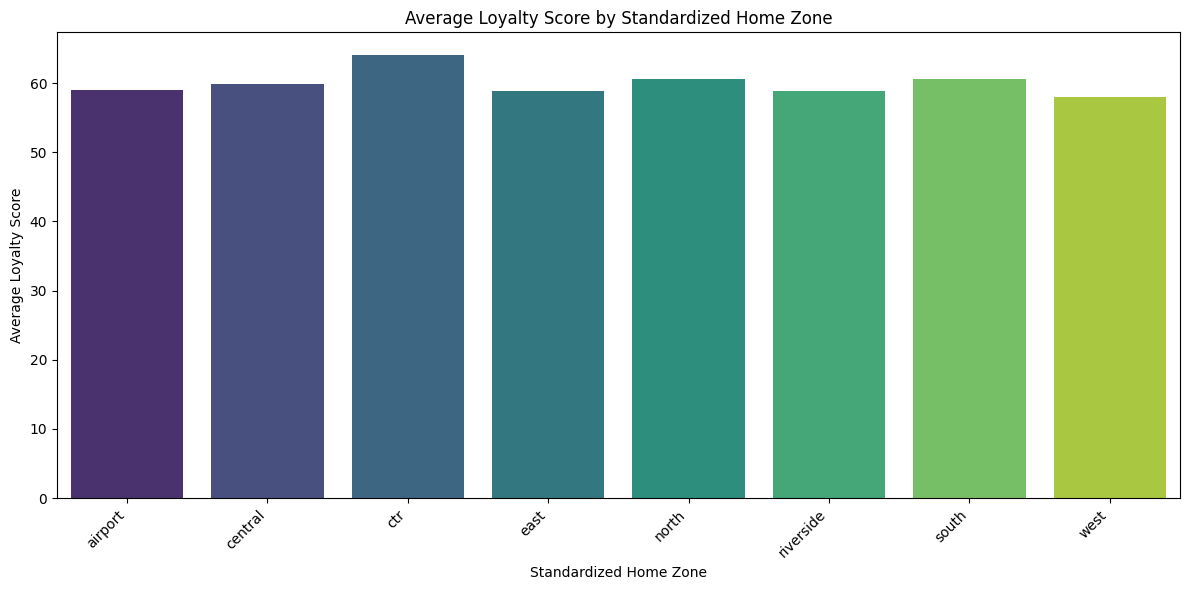

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os

# Define the CSV file path for robust loading
csv_file_path = 'northstar_dataset/northstar_dataset/customers.csv'

# Ensure df_customers is loaded and processed
if 'df_customers' not in globals() or df_customers.empty or 'home_zone_standardized' not in df_customers.columns:
    print("df_customers not found, empty, or 'home_zone_standardized' column missing. Attempting to load and process...")
    if os.path.exists(csv_file_path):
        df_customers = pd.read_csv(csv_file_path)
        print("df_customers loaded successfully.")
        # Standardize home_zone, as done in previous steps
        df_customers['home_zone_standardized'] = df_customers['home_zone'].str.lower().str.strip()
    else:
        raise FileNotFoundError(f"'{csv_file_path}' not found. Please ensure the dataset is extracted and loaded.")

# Recalculate average loyalty score using the standardized home_zone column
average_loyalty_by_zone_standardized = df_customers.groupby('home_zone_standardized')['loyalty_score'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(x='home_zone_standardized', y='loyalty_score', data=average_loyalty_by_zone_standardized, palette='viridis', hue='home_zone_standardized', legend=False)
plt.title('Average Loyalty Score by Standardized Home Zone')
plt.xlabel('Standardized Home Zone')
plt.ylabel('Average Loyalty Score')
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
plt.tight_layout()
plt.show()

In [20]:
# Standardize the home_zone column by converting to lowercase and stripping whitespace
df_customers['home_zone_standardized'] = df_customers['home_zone'].str.lower().str.strip()

# Recalculate average loyalty score using the standardized home_zone column
average_loyalty_by_zone_standardized = df_customers.groupby('home_zone_standardized')['loyalty_score'].mean().reset_index()
display(average_loyalty_by_zone_standardized)

,home_zone_standardized,loyalty_score
0,airport,58.989584
1,central,59.942614
2,ctr,64.011837
3,east,58.947788
4,north,60.599663
5,riverside,58.807692
6,south,60.556318
7,west,58.012074


In [16]:
import pandas as pd
import os

# Define the CSV file path, which was previously confirmed to exist after extraction.
csv_file_path = 'northstar_dataset/northstar_dataset/customers.csv'

# Check if df_customers is defined, and if not, load it.
# This makes the cell more robust against kernel restarts or out-of-order execution.
if 'df_customers' not in globals():
    if os.path.exists(csv_file_path):
        df_customers = pd.read_csv(csv_file_path)
        print(f"'df_customers' loaded from {csv_file_path}.")
    else:
        # Fallback if the file isn't found (though it should be after previous steps)
        raise FileNotFoundError(f"'{csv_file_path}' not found. Please ensure the dataset is extracted.")
elif df_customers.empty:
    # If it's defined but empty (e.g., if it was overwritten or cleared)
    if os.path.exists(csv_file_path):
        df_customers = pd.read_csv(csv_file_path)
        print(f"'df_customers' reloaded from {csv_file_path} because it was empty.")
    else:
        raise FileNotFoundError(f"'{csv_file_path}' not found. Please ensure the dataset is extracted.")

# Original code to calculate customer count by home_zone
customer_count_by_zone = df_customers.groupby('home_zone')['customer_id'].count().reset_index()
customer_count_by_zone.rename(columns={'customer_id': 'customer_count'}, inplace=True)
display(customer_count_by_zone)

'df_customers' loaded from northstar_dataset/northstar_dataset/customers.csv.


,home_zone,customer_count
0,AIRPORT,34
1,Airport,35
2,CENTRAL,44
3,Central,33
4,Ctr,33
5,EAST,41
6,East,48
7,NORTH,33
8,North,39
9,RiverSide,49


In [17]:
display(df_customers.head())

,customer_id,age,home_zone,customer_type,signup_date,loyalty_score,app_engagement_score,preferred_channel,account_status
0,C0001,26,North,SME,2024-11-27 04:25:00,44.9,69.2,App,Active
1,C0002,61,AIRPORT,Consumer,2025-10-28 01:04:00,55.4,66.6,App,Active
2,C0003,66,East,Consumer,2025-07-02 03:23:00,75.9,33.8,NaN,Active
3,C0004,75,CENTRAL,Consumer,2025-08-19 01:58:00,32.5,33.0,App,Active
4,C0005,26,Riverside,Consumer,2025-06-03 06:02:00,55.9,100.0,Web,Active


df_customers not found, empty, or 'home_zone_standardized' column missing. Attempting to load and process...
df_customers loaded successfully.


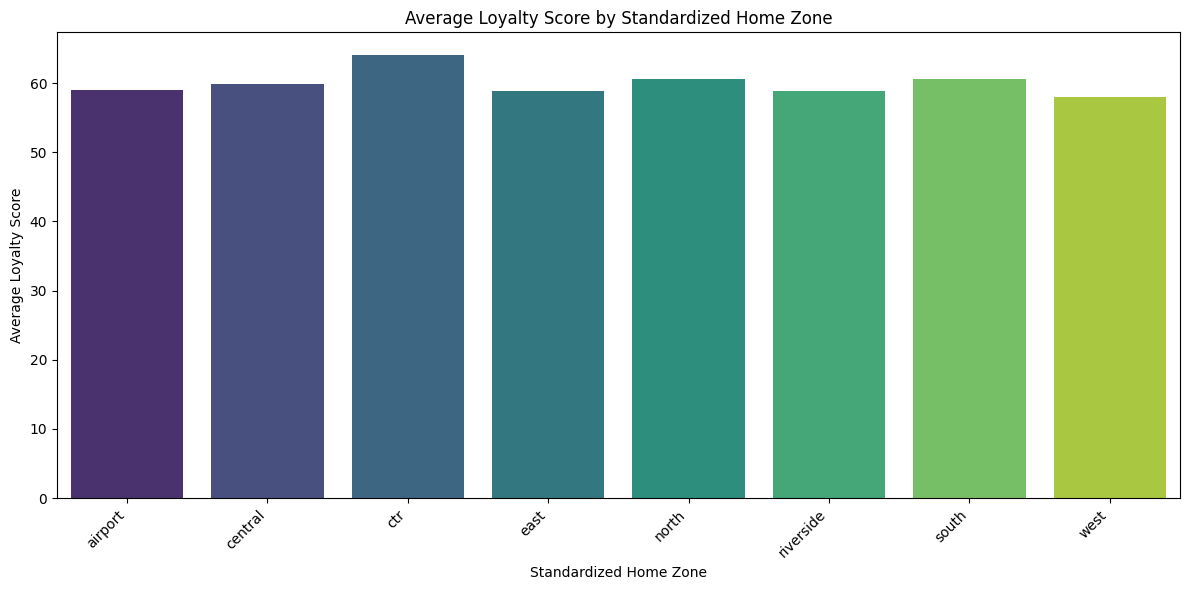

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import zipfile
from google.colab import files

# Define paths (if needed for robust loading)
csv_file_path = 'northstar_dataset/northstar_dataset/customers.csv'
zip_file_name = 'northstar_dataset.zip'
extracted_base_dir = 'northstar_dataset'

# Ensure df_customers is loaded and processed
if 'df_customers' not in locals() or df_customers.empty or 'home_zone_standardized' not in df_customers.columns:
    print("df_customers not found, empty, or 'home_zone_standardized' column missing. Attempting to load and process...")

    # Robustly load df_customers if not available
    if not os.path.exists(csv_file_path):
        # Check if the zip file is in 'uploaded' or on disk to extract
        if not os.path.exists(zip_file_name) and 'uploaded' in globals() and zip_file_name in files.uploaded:
            try:
                zip_content = files.uploaded[zip_file_name]
                with open(zip_file_name, 'wb') as f:
                    f.write(zip_content)
                print(f"'{zip_file_name}' saved from 'uploaded' to disk.")
            except Exception as e:
                print(f"Error saving '{zip_file_name}' from 'uploaded': {e}")
                raise FileNotFoundError(f"Failed to ensure '{zip_file_name}' is on disk.")

        if os.path.exists(zip_file_name):
            try:
                with zipfile.ZipFile(zip_file_name, 'r') as zip_ref:
                    zip_ref.extractall(extracted_base_dir)
                print("Zip file extracted successfully.")
            except Exception as e:
                print(f"Error during zip extraction: {e}")
                raise FileNotFoundError(f"Failed to extract '{zip_file_name}' to get '{csv_file_path}'.")
        else:
            raise FileNotFoundError(f"Cannot find '{zip_file_name}' to extract '{csv_file_path}'. Please upload it using files.upload().")

    df_customers = pd.read_csv(csv_file_path)
    print("df_customers loaded successfully.")

    # Standardize home_zone (as done in previous cells)
    df_customers['home_zone_standardized'] = df_customers['home_zone'].str.lower().str.strip()

# Calculate average loyalty score by standardized home zone
average_loyalty_by_zone_standardized = df_customers.groupby('home_zone_standardized')['loyalty_score'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(x='home_zone_standardized', y='loyalty_score', data=average_loyalty_by_zone_standardized, palette='viridis', hue='home_zone_standardized', legend=False)
plt.title('Average Loyalty Score by Standardized Home Zone')
plt.xlabel('Standardized Home Zone')
plt.ylabel('Average Loyalty Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [21]:
import pandas as pd
import os
import zipfile
from google.colab import files

# Define paths
csv_file_path = 'northstar_dataset/northstar_dataset/customers.csv'
zip_file_name = 'northstar_dataset.zip'
extracted_base_dir = 'northstar_dataset'

# Ensure df_customers is loaded
if 'df_customers' not in locals() or df_customers.empty:
    print("df_customers not found or empty. Attempting to load...")
    if not os.path.exists(csv_file_path):
        print(f"'{csv_file_path}' not found. Attempting to extract from '{zip_file_name}'.")
        # Check if the zip file is in 'uploaded' or on disk to extract
        if not os.path.exists(zip_file_name) and 'uploaded' in globals() and zip_file_name in files.uploaded:
            try:
                zip_content = files.uploaded[zip_file_name]
                with open(zip_file_name, 'wb') as f:
                    f.write(zip_content)
                print(f"'{zip_file_name}' saved from 'uploaded' to disk.")
            except Exception as e:
                print(f"Error saving '{zip_file_name}' from 'uploaded': {e}")
                raise FileNotFoundError(f"Failed to ensure '{zip_file_name}' is on disk.")

        if os.path.exists(zip_file_name):
            try:
                with zipfile.ZipFile(zip_file_name, 'r') as zip_ref:
                    zip_ref.extractall(extracted_base_dir)
                print("Zip file extracted successfully.")
            except Exception as e:
                print(f"Error during zip extraction: {e}")
                raise FileNotFoundError(f"Failed to extract '{zip_file_name}' to get '{csv_file_path}'.")
        else:
            raise FileNotFoundError(f"Cannot find '{zip_file_name}' to extract '{csv_file_path}'. Please upload it using files.upload().")

    df_customers = pd.read_csv(csv_file_path)
    print("df_customers loaded successfully.")

# Calculate customer count by home_zone
customer_count_by_zone = df_customers.groupby('home_zone')['customer_id'].count().reset_index()
customer_count_by_zone.rename(columns={'customer_id': 'customer_count'}, inplace=True)
display(customer_count_by_zone)

,home_zone,customer_count
0,AIRPORT,34
1,Airport,35
2,CENTRAL,44
3,Central,33
4,Ctr,33
5,EAST,41
6,East,48
7,NORTH,33
8,North,39
9,RiverSide,49


In [14]:
import os
from google.colab import files

zip_file_name = 'northstar_dataset.zip'

# Check if the zip file is in the 'uploaded' dictionary
if 'uploaded' in globals() and zip_file_name in uploaded:
    print(f"'{zip_file_name}' found in the 'uploaded' object.")

    # Check if the zip file exists on disk
    if not os.path.exists(zip_file_name):
        try:
            zip_content = uploaded[zip_file_name]
            with open(zip_file_name, 'wb') as f:
                f.write(zip_content)
            print(f"'{zip_file_name}' saved from 'uploaded' to disk.")
        except Exception as e:
            print(f"Error saving '{zip_file_name}' from 'uploaded' to disk: {e}")
    else:
        print(f"'{zip_file_name}' already exists on disk.")
else:
    print(f"'{zip_file_name}' not found in the 'uploaded' object. Please ensure it was uploaded using files.upload().")

# Verify its presence on disk again after potential saving
if os.path.exists(zip_file_name):
    print(f"Final check: '{zip_file_name}' is confirmed to be on disk.")
else:
    print(f"Final check: '{zip_file_name}' is NOT on disk.")

'northstar_dataset.zip' found in the 'uploaded' object.
'northstar_dataset.zip' already exists on disk.
Final check: 'northstar_dataset.zip' is confirmed to be on disk.


In [38]:
df_customers

,customer_id,age,home_zone,customer_type,signup_date,loyalty_score,app_engagement_score,preferred_channel,account_status
0,C0001,26,North,SME,2024-11-27 04:25:00,44.900000,69.2,App,Active
1,C0002,61,AIRPORT,Consumer,2025-10-28 01:04:00,55.400000,66.6,App,Active
2,C0003,66,East,Consumer,2025-07-02 03:23:00,75.900000,33.8,App,Active
3,C0004,75,CENTRAL,Consumer,2025-08-19 01:58:00,32.500000,33.0,App,Active
4,C0005,26,Riverside,Consumer,2025-06-03 06:02:00,55.900000,100.0,Web,Active
...,...,...,...,...,...,...,...,...,...
645,C0646,64,SOUTH,SME,2024-12-25 08:59:00,71.400000,32.6,App,Active
646,C0647,42,East,Consumer,2024-10-16 01:45:00,59.690635,76.1,App,Active
647,C0648,47,Airport,Consumer,2025-01-11 10:49:00,57.200000,74.0,App,Active
648,C0649,75,CENTRAL,Enterprise,2025-09-08 16:30:00,42.100000,34.4,App,Active


In [39]:
import pandas as pd

missing_summary = pd.DataFrame({
    "Field": ["loyalty_score", "preferred_channel"],
    "Missing Values": [
        df_customers["loyalty_score"].isnull().sum(),
        df_customers["preferred_channel"].isnull().sum()
    ]
})

missing_summary

,Field,Missing Values
0,loyalty_score,0
1,preferred_channel,0


In [41]:
import pandas as pd
import os
import zipfile
from google.colab import files

# Define paths for robust loading
csv_file_path = 'northstar_dataset/northstar_dataset/customers.csv'
zip_file_name = 'northstar_dataset.zip'
extracted_base_dir = 'northstar_dataset'

# Ensure the customers.csv is available and loaded into df_customers_raw
if not os.path.exists(csv_file_path):
    print(f"'{csv_file_path}' not found. Attempting to extract from '{zip_file_name}'.")

    # Ensure the zip file is on disk, either from previous upload or from 'uploaded' dict
    if not os.path.exists(zip_file_name):
        if 'uploaded' in globals() and zip_file_name in files.uploaded:
            try:
                zip_content = files.uploaded[zip_file_name]
                with open(zip_file_name, 'wb') as f:
                    f.write(zip_content)
                print(f"'{zip_file_name}' saved from 'uploaded' to disk.")
            except Exception as e:
                print(f"Error saving '{zip_file_name}' from 'uploaded': {e}")
                raise FileNotFoundError(f"Failed to ensure '{zip_file_name}' is on disk.")
        else:
            # If zip not on disk and not in uploaded, it's truly missing.
            raise FileNotFoundError(f"'{zip_file_name}' not found. Please ensure it's uploaded using files.upload().")

    # Now that we ensured zip_file_name is on disk, proceed with extraction
    try:
        with zipfile.ZipFile(zip_file_name, 'r') as zip_ref:
            zip_ref.extractall(extracted_base_dir)
        print("Zip file extracted successfully.")
    except Exception as e:
        print(f"Error during zip extraction: {e}")
        raise FileNotFoundError(f"Failed to extract '{zip_file_name}' to get '{csv_file_path}'.")

df_customers_raw = pd.read_csv(csv_file_path)

missing_summary_before = pd.DataFrame({
    "Field": ["loyalty_score", "preferred_channel"],
    "Missing Values Before Cleaning": [
        df_customers_raw["loyalty_score"].isnull().sum(),
        df_customers_raw["preferred_channel"].isnull().sum()
    ]
})

missing_summary_before

,Field,Missing Values Before Cleaning
0,loyalty_score,20
1,preferred_channel,13


In [42]:
df_customers_cleaned = df_customers_raw.copy()

# Fill missing loyalty_score with mean
df_customers_cleaned["loyalty_score"] = df_customers_cleaned["loyalty_score"].fillna(
    df_customers_cleaned["loyalty_score"].mean()
)

# Fill missing preferred_channel with mode
df_customers_cleaned["preferred_channel"] = df_customers_cleaned["preferred_channel"].fillna(
    df_customers_cleaned["preferred_channel"].mode()[0]
)

missing_summary_after = pd.DataFrame({
    "Field": ["loyalty_score", "preferred_channel"],
    "Missing Values After Cleaning": [
        df_customers_cleaned["loyalty_score"].isnull().sum(),
        df_customers_cleaned["preferred_channel"].isnull().sum()
    ]
})

missing_summary_after

,Field,Missing Values After Cleaning
0,loyalty_score,0
1,preferred_channel,0


In [43]:
# Fill missing preferred_channel with the most common value
df_customers["preferred_channel"] = df_customers["preferred_channel"].fillna(
    df_customers["preferred_channel"].mode()[0]
)

# Check missing values after filling
print("Missing values in preferred_channel after filling:",
      df_customers["preferred_channel"].isnull().sum())

Missing values in preferred_channel after filling: 0


In [44]:
import pandas as pd

# Convert signup_date column to datetime format
df_customers["signup_date"] = pd.to_datetime(df_customers["signup_date"])

# Check dataset information after date conversion
df_customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 650 entries, 0 to 649
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   customer_id           650 non-null    object        
 1   age                   650 non-null    int64         
 2   home_zone             650 non-null    object        
 3   customer_type         650 non-null    object        
 4   signup_date           650 non-null    datetime64[ns]
 5   loyalty_score         650 non-null    float64       
 6   app_engagement_score  650 non-null    float64       
 7   preferred_channel     650 non-null    object        
 8   account_status        650 non-null    object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(5)
memory usage: 45.8+ KB


In [45]:
import pandas as pd

# Load customers dataset
df_customers = pd.read_csv("northstar_dataset/northstar_dataset/customers.csv")

# Average loyalty score by original home_zone
zone_before = df_customers.groupby("home_zone")["loyalty_score"].mean().reset_index()

zone_before

,home_zone,loyalty_score
0,AIRPORT,59.709375
1,Airport,58.291429
2,CENTRAL,59.179545
3,Central,61.041935
4,Ctr,64.146875
5,EAST,56.150000
6,East,61.178261
7,NORTH,62.390625
8,North,59.755263
9,RiverSide,56.902041


In [46]:
import pandas as pd

# Standardise zone names
def standardize_zone(x):
    x = str(x).strip().lower()
    if x == "ctr":
        return "central"
    return x

df_customers["home_zone_standardized"] = df_customers["home_zone"].apply(standardize_zone)

# Average loyalty score by standardised home zone
zone_after = df_customers.groupby("home_zone_standardized")["loyalty_score"].mean().reset_index()

# Round values
zone_after["loyalty_score"] = zone_after["loyalty_score"].round(2)

zone_after

,home_zone_standardized,loyalty_score
0,airport,58.97
1,central,61.20
2,east,58.90
3,north,60.63
4,riverside,58.81
5,south,60.58
6,west,57.93


In [1]:
import pandas as pd

problem_matrix = pd.DataFrame({
    "Problem Area": [
        "Fragmented data systems",
        "Service reliability issues",
        "Zone and hub performance differences",
        "Poor customer experience visibility",
        "Weak cost and profitability visibility",
        "Vehicle maintenance and downtime",
        "Need for flexible data storage"
    ],
    "Evidence from Case Study": [
        "Data is stored separately across old and new systems",
        "Delays, missed windows and failed services are increasing",
        "Some city zones and hubs perform worse than others",
        "Complaints, failed journeys and incidents are not connected",
        "Cost, service and exception data are stored separately",
        "Fault events, scheduling and route assignments are not analysed together",
        "App events, complaints, GPS logs and case histories are nested and variable"
    ],
    "Business Impact": [
        "Managers cannot see the full operational picture",
        "Customer satisfaction and service quality decrease",
        "Management cannot identify weak locations clearly",
        "Customer problems cannot be investigated properly",
        "Finance team cannot identify loss-making services accurately",
        "Vehicle downtime increases and affects delivery performance",
        "Relational-only database design becomes difficult to maintain"
    ],
    "Data Needed for Analysis": [
        "customers, orders, deliveries, complaints, incidents, app_events",
        "orders, deliveries, complaints",
        "orders, deliveries, hubs",
        "customers, complaints, incidents, app_events, deliveries",
        "orders, deliveries, complaints, costs",
        "vehicles, incidents, deliveries",
        "complaints, app_events, incidents, service case records"
    ]
})

problem_matrix

,Problem Area,Evidence from Case Study,Business Impact,Data Needed for Analysis
0,Fragmented data systems,Data is stored separately across old and new s...,Managers cannot see the full operational picture,"customers, orders, deliveries, complaints, inc..."
1,Service reliability issues,"Delays, missed windows and failed services are...",Customer satisfaction and service quality decr...,"orders, deliveries, complaints"
2,Zone and hub performance differences,Some city zones and hubs perform worse than ot...,Management cannot identify weak locations clearly,"orders, deliveries, hubs"
3,Poor customer experience visibility,"Complaints, failed journeys and incidents are ...",Customer problems cannot be investigated properly,"customers, complaints, incidents, app_events, ..."
4,Weak cost and profitability visibility,"Cost, service and exception data are stored se...",Finance team cannot identify loss-making servi...,"orders, deliveries, complaints, costs"
5,Vehicle maintenance and downtime,"Fault events, scheduling and route assignments...",Vehicle downtime increases and affects deliver...,"vehicles, incidents, deliveries"
6,Need for flexible data storage,"App events, complaints, GPS logs and case hist...",Relational-only database design becomes diffic...,"complaints, app_events, incidents, service cas..."


In [3]:
stakeholder_matrix = pd.DataFrame({
    "Stakeholder": [
        "Operations Director",
        "Customer Experience Director",
        "Finance Director",
        "Technology Director"
    ],
    "Main Concern": [
        "Poor route allocation and underperforming hubs",
        "Complaints, missed journeys, failed deliveries and incidents are not connected",
        "Some routes and service contracts may be unprofitable",
        "Current database structure cannot handle volume and variety of data"
    ],
    "Evidence Needed": [
        "Delivery status, route distance, hub, zone and route override data",
        "Complaint records, delivery records, customer ratings and incident records",
        "Order value, fuel/charge cost, compensation and service failure data",
        "App events, complaint histories, route exceptions and nested case histories"
    ],
    "Suitable Analysis Method": [
        "SQL/R/Python analysis by zone, hub and route",
        "Joined analysis of complaints, deliveries and incidents",
        "Contribution proxy and cost-related analysis",
        "MongoDB document model and aggregation pipelines"
    ]
})

stakeholder_matrix

,Stakeholder,Main Concern,Evidence Needed,Suitable Analysis Method
0,Operations Director,Poor route allocation and underperforming hubs,"Delivery status, route distance, hub, zone and...","SQL/R/Python analysis by zone, hub and route"
1,Customer Experience Director,"Complaints, missed journeys, failed deliveries...","Complaint records, delivery records, customer ...","Joined analysis of complaints, deliveries and ..."
2,Finance Director,Some routes and service contracts may be unpro...,"Order value, fuel/charge cost, compensation an...",Contribution proxy and cost-related analysis
3,Technology Director,Current database structure cannot handle volum...,"App events, complaint histories, route excepti...",MongoDB document model and aggregation pipelines


In [2]:
analysis_questions = pd.DataFrame({
    "Analytical Question": [
        "Which zones and hubs have the highest failure and delay rates?",
        "Which service types create the highest operational risk?",
        "Are complaints linked to failed or delayed deliveries?",
        "Are vehicle maintenance issues linked to poor delivery outcomes?",
        "Do route overrides indicate possible routing problems?",
        "Can MongoDB support a single case-level operational view?"
    ],
    "Data Sources Required": [
        "orders, deliveries, hubs",
        "orders, deliveries, complaints",
        "complaints, deliveries, customers",
        "vehicles, incidents, deliveries",
        "deliveries, orders, route fields",
        "customers, orders, deliveries, complaints, incidents, app_events"
    ],
    "Planned Method": [
        "Group by zone and hub; calculate failure and delay rates",
        "Compare service type against failure, delay and complaint rates",
        "Join complaint records with delivery outcomes",
        "Join vehicle maintenance data with delivery and incident data",
        "Compare manual route override groups with delivery outcomes",
        "Design service_cases collection in MongoDB Atlas"
    ]
})

analysis_questions

,Analytical Question,Data Sources Required,Planned Method
0,Which zones and hubs have the highest failure ...,"orders, deliveries, hubs",Group by zone and hub; calculate failure and d...
1,Which service types create the highest operati...,"orders, deliveries, complaints","Compare service type against failure, delay an..."
2,Are complaints linked to failed or delayed del...,"complaints, deliveries, customers",Join complaint records with delivery outcomes
3,Are vehicle maintenance issues linked to poor ...,"vehicles, incidents, deliveries",Join vehicle maintenance data with delivery an...
4,Do route overrides indicate possible routing p...,"deliveries, orders, route fields",Compare manual route override groups with deli...
5,Can MongoDB support a single case-level operat...,"customers, orders, deliveries, complaints, inc...",Design service_cases collection in MongoDB Atlas
